In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
emb_df = np.load("hm_fashion_embeddings.npz")

In [3]:
emb_df

NpzFile 'hm_fashion_embeddings.npz' with keys: article_ids, image_embeddings, text_embeddings

In [4]:
article_ids = emb_df['article_ids']
image_embeddings = emb_df['image_embeddings']
text_embeddings = emb_df['text_embeddings']
emb_df.close()

In [5]:
article_ids

array(['0108775015', '0108775044', '0108775051', ..., '0956217002',
       '0957375001', '0959461001'], shape=(105542,), dtype='<U10')

In [6]:
image_embeddings

array([[ 1.8060164e-03,  3.0106739e-03,  6.3627646e-03, ...,
        -3.5103839e-02, -7.3001087e-02,  8.9078704e-03],
       [-7.0716289e-04,  4.7017802e-03, -4.3832725e-03, ...,
        -4.1223995e-02, -2.1628188e-02,  1.0616923e-03],
       [-9.8827006e-03, -6.9442946e-03,  5.4468014e-03, ...,
        -4.3031242e-02, -2.1832470e-02,  6.0276929e-03],
       ...,
       [-2.2315620e-02,  8.0912330e-05, -9.8389387e-03, ...,
        -1.4192022e-02, -7.5216100e-02, -1.1408638e-02],
       [ 9.7095072e-03, -3.6617890e-02,  1.6146472e-02, ...,
        -9.0823900e-03, -9.0881571e-02,  2.8688820e-02],
       [ 2.1738645e-02, -2.6764922e-02, -2.9639322e-02, ...,
        -2.5414109e-02, -1.9665306e-02,  1.1426925e-02]],
      shape=(105542, 768), dtype=float32)

In [7]:
text_embeddings

array([[ 0.01174036, -0.00159475,  0.01038124, ...,  0.00605117,
         0.00313657,  0.01710172],
       [ 0.01174036, -0.00159475,  0.01038124, ...,  0.00605117,
         0.00313657,  0.01710172],
       [ 0.00708578, -0.01122681,  0.02939075, ..., -0.0237561 ,
         0.00336769, -0.00260496],
       ...,
       [-0.02051743,  0.02258208, -0.02358215, ..., -0.02472738,
         0.0500677 , -0.00106761],
       [ 0.03140646, -0.01555131,  0.03248373, ..., -0.02741505,
         0.0061563 ,  0.02491524],
       [ 0.02228456, -0.00194288, -0.01643252, ..., -0.02423524,
         0.03255294, -0.00781832]], shape=(105542, 768), dtype=float32)

In [8]:
multimodal_embeddings = np.concatenate([image_embeddings, text_embeddings], axis=1)

In [9]:
multimodal_embeddings = image_embeddings

In [10]:
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans

# Keep the feature matrix compact; PCA and K-Means accept float32 inputs.
multimodal_embeddings = np.asarray(multimodal_embeddings, dtype=np.float32)
assert multimodal_embeddings.ndim == 2
assert multimodal_embeddings.shape[0] == len(article_ids)
assert np.isfinite(multimodal_embeddings).all()

n_components = min(50, multimodal_embeddings.shape[0], multimodal_embeddings.shape[1])
pca = PCA(n_components=n_components, svd_solver="randomized", random_state=42)
reduced_embeddings = pca.fit_transform(multimodal_embeddings)

n_clusters = 50
kmeans = MiniBatchKMeans(
    n_clusters=n_clusters,
    batch_size=4096,
    n_init=3,
    random_state=42,
)
cluster_labels = kmeans.fit_predict(reduced_embeddings)

print(f"Input shape: {multimodal_embeddings.shape}")
print(f"PCA shape: {reduced_embeddings.shape}")
print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.1%}")
print(f"Clusters: {np.unique(cluster_labels).size}; assigned rows: {len(cluster_labels):,}")

Input shape: (105542, 768)
PCA shape: (105542, 50)
Cumulative explained variance: 64.4%
Clusters: 50; assigned rows: 105,542


In [11]:
from pathlib import Path
import textwrap


def normalize_article_id(value):
    if isinstance(value, bytes):
        value = value.decode("utf-8")
    return str(value).zfill(10)


articles = pd.read_csv("articles.csv", dtype={"article_id": str})
articles["article_id"] = articles["article_id"].str.zfill(10)
clustered_articles = pd.DataFrame({
    "article_id": [normalize_article_id(value) for value in article_ids],
    "cluster": cluster_labels,
}).merge(articles, on="article_id", how="left", validate="one_to_one")

print(f"Articles matched to catalog: {clustered_articles['prod_name'].notna().sum():,} / {len(clustered_articles):,}")


def plot_cluster_examples(cluster_id, n=6, image_root="images", random_state=42):
    cluster_rows = clustered_articles.loc[clustered_articles["cluster"] == cluster_id]
    if cluster_rows.empty:
        raise ValueError(f"Cluster {cluster_id} has no articles")

    examples = cluster_rows.sample(n=min(n, len(cluster_rows)), random_state=random_state)
    ncols = min(3, len(examples))
    nrows = int(np.ceil(len(examples) / ncols))
    figure, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)
    image_root = Path(image_root)

    for axis, row in zip(axes.flat, examples.itertuples(index=False)):
        article_id = row.article_id
        image_path = image_root / article_id[:3] / f"{article_id}.jpg"
        if image_path.exists():
            axis.imshow(plt.imread(image_path))
        else:
            axis.text(0.5, 0.5, f"Image not found\n{image_path}", ha="center", va="center", wrap=True)

        product_name = row.prod_name if pd.notna(row.prod_name) else "Unknown product"
        description = row.detail_desc if pd.notna(row.detail_desc) else "No description available"
        description = textwrap.fill(description[:180], width=42)
        if len(row.detail_desc) > 180 if pd.notna(row.detail_desc) else False:
            description += "..."
        axis.set_title(f"{article_id} | {product_name}\n{description}", fontsize=8, loc="left", wrap=True)
        axis.axis("off")

    for axis in axes.flat[len(examples):]:
        axis.axis("off")
    figure.suptitle(f"Cluster {cluster_id} ({len(cluster_rows):,} articles)", fontsize=14)
    figure.tight_layout()
    plt.show()


def plot_all_cluster_examples(n=4, image_root="images", random_state=42):
    for cluster_id in range(n_clusters):
        plot_cluster_examples(cluster_id, n=n, image_root=image_root, random_state=random_state)


# Example: plot_cluster_examples(0, n=6, image_root="images")

Articles matched to catalog: 105,542 / 105,542


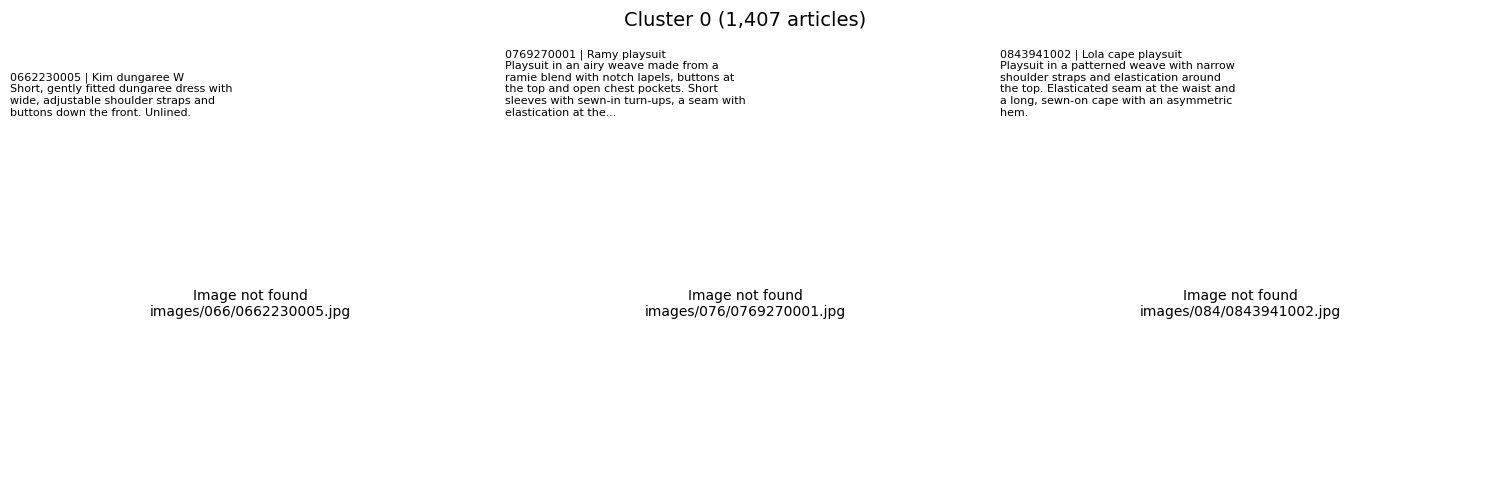

In [12]:
plot_cluster_examples(0, n=3, image_root="images")

In [13]:
profile_columns = [
    "product_type_name",
    "product_group_name",
    "department_name",
    "colour_group_name",
    "index_group_name",
]

def top_values(series, n=3):
    counts = series.dropna().value_counts().head(n)
    total = series.notna().sum()
    return "; ".join(
        f"{value} ({count / total:.0%})"
        for value, count in counts.items()
    )

profiles = []
for cluster_id, group in clustered_articles.groupby("cluster"):
    row = {"cluster": cluster_id, "n_articles": len(group)}
    for column in profile_columns:
        row[column] = top_values(group[column])
    profiles.append(row)

cluster_profiles = (
    pd.DataFrame(profiles)
    .sort_values("n_articles", ascending=False)
)
display(cluster_profiles)

,cluster,n_articles,product_type_name,product_group_name,department_name,colour_group_name,index_group_name
9,9,4576,Trousers (78%); Leggings/Tights (17%); Pyjama ...,Garment Lower body (97%); Nightwear (3%); Unkn...,Trouser (30%); Jersey (8%); Ladies Sport Botto...,Black (42%); Dark Blue (11%); Dark Grey (6%),Ladieswear (46%); Menswear (17%); Divided (13%)
6,6,4523,Sweater (91%); Top (5%); Dress (2%),Garment Upper body (98%); Garment Full body (2...,Knitwear (51%); Tops Knitwear (10%); Jersey/Kn...,Black (14%); Grey (9%); Dark Blue (8%),Ladieswear (53%); Menswear (22%); Divided (17%)
2,2,3822,Trousers (95%); Leggings/Tights (2%); Dungaree...,Garment Lower body (98%); Garment Full body (1...,Trouser (15%); Denim Trousers (12%); Trousers ...,Blue (23%); Dark Blue (20%); Black (18%),Baby/Children (35%); Divided (26%); Ladieswear...
11,11,2948,Hoodie (61%); Sweater (26%); Jacket (4%),Garment Upper body (98%); Garment Full body (1...,Jersey Fancy (15%); Young Boy Jersey Fancy (8%...,Black (21%); Dark Blue (12%); Grey (11%),Baby/Children (37%); Menswear (27%); Divided (...
23,23,2861,Shirt (85%); Blouse (6%); Dress (2%),Garment Upper body (95%); Nightwear (2%); Garm...,Shirt (34%); Blouse (12%); Kids Boy Shirt (9%),Dark Blue (18%); White (16%); Light Blue (10%),Menswear (45%); Baby/Children (23%); Ladieswea...
46,46,2859,T-shirt (79%); Vest top (7%); Top (4%),Garment Upper body (92%); Nightwear (3%); Garm...,Young Girl Jersey Fancy (15%); Young Boy Jerse...,White (30%); Black (12%); Dark Blue (9%),Baby/Children (58%); Menswear (14%); Divided (...
15,15,2701,Skirt (86%); Shorts (8%); Trousers (4%),Garment Lower body (98%); Swimwear (1%); Garme...,Skirt (25%); Skirts (16%); Projects Woven Bott...,Black (33%); Dark Blue (8%); White (6%),Ladieswear (58%); Divided (30%); Baby/Children...
10,10,2605,Top (33%); Sweater (27%); Blouse (21%),Garment Upper body (98%); Garment Full body (1...,Jersey (14%); Tops Fancy Jersey (14%); Tops Kn...,Black (38%); White (20%); Off White (4%),Divided (45%); Ladieswear (43%); Baby/Children...
28,28,2507,Dress (71%); Garment Set (5%); Jumpsuit/Playsu...,Garment Full body (81%); Garment Upper body (1...,Kids Girl Jersey Fancy (22%); Kids Girl Dresse...,Light Pink (19%); Dark Blue (12%); White (11%),Baby/Children (97%); Ladieswear (1%); Divided ...
49,49,2501,T-shirt (65%); Top (16%); Sweater (8%),Garment Upper body (93%); Garment Full body (6...,Jersey (23%); Jersey Basic (16%); Basic 1 (11%),White (14%); Light Pink (8%); Greenish Khaki (7%),Ladieswear (49%); Divided (22%); Menswear (15%)


In [ ]:
centers_for_articles = kmeans.cluster_centers_[cluster_labels]
clustered_articles["centroid_distance"] = np.linalg.norm(
    reduced_embeddings - centers_for_articles,
    axis=1,
)

def inspect_cluster(cluster_id, n=8):
    display(cluster_profiles.loc[cluster_profiles["cluster"] == cluster_id].T)
    examples = (
        clustered_articles.loc[clustered_articles["cluster"] == cluster_id]
        .nsmallest(n, "centroid_distance")
    )
    display(examples[
        ["article_id", "prod_name", "product_type_name", "detail_desc"]
    ])

inspect_cluster(1)

,0
cluster,0
n_articles,1407
product_type_name,Dress (48%); Jumpsuit/Playsuit (20%); Trousers...
product_group_name,Garment Full body (73%); Garment Lower body (1...
department_name,Dresses (15%); Young Girl Dresses (8%); Dress ...
colour_group_name,Dark Blue (21%); White (17%); Blue (14%)
index_group_name,Baby/Children (37%); Ladieswear (35%); Divided...


,article_id,prod_name,product_type_name,detail_desc
83798,0813421003,APPLE JUMPSUIT,Dress,Off-the-shoulder playsuit in an airy viscose w...
81601,0806073002,Jude Jumpsuit deal,Jumpsuit/Playsuit,Sleeveless playsuit in a soft viscose weave wi...
61537,0733470003,DALIA maxi dress,Dress,"Maxi dress in soft, printed organic cotton jer..."
71202,0763178001,Toto jumpsuit,Trousers,Jumpsuit in a crinkled viscose weave with a sm...
41312,0668174001,Cannes dress,Dress,"Short dress in woven fabric with a V-neck, but..."
65215,0744040001,Caen wrap dress,Dress,Dress in a striped cotton and viscose weave wi...
83795,0813420004,VEGA JUMPSUIT,Dress,"Playsuit in an airy, patterned viscose weave w..."
48982,0693607008,Jude jumpsuit,Jumpsuit/Playsuit,Sleeveless playsuit in a soft viscose weave wi...
